<a href="https://colab.research.google.com/github/Maanvijangir/Github-demo/blob/main/plant_village_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maanvi

# Importing dataset from Colab and mounting to drive

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username" : "maanvijangir",\r\n  "key" : "KGAT_fe15e274164d1eef4d46da385bf0fc7f"\r\n}'}

In [ ]:
import os
os.makedirs('/root/.kaggle',exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


!chmod cmd --- changes the file permissions of kaggle.json,
600 means ->owner can read and write
->no one else can access the file

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d moazawadali/plantvillage-tomato -p /content/drive/MyDrive/


Dataset URL: https://www.kaggle.com/datasets/moazawadali/plantvillage-tomato
License(s): DbCL-1.0
plantvillage-tomato.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/drive/MyDrive/plantvillage-tomato.zip -d /content/drive/MyDrive/

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9cfa3f33-36c3-4812-9d23-73898c39d8db___UF.GRC_YLCV_Lab 01362.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d00f458-5616-470e-a8ad-9694c01999bb___YLCV_NREC 2276.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d032375-b1ce-45ca-a067-e699486d511d___YLCV_GCREC 2220.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d101a85-6847-4e83-87bc-63f0794f0032___YLCV_GCREC 2763.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d1f2f28-34e4-45ca-9517-e9410054ba5f___YLCV_GCREC 2503.JPG  
  inflating: /content/drive/MyDrive/PlantVillage/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus/9d220ab4-26b6-4367-956b-59b625501152___YLCV_NREC 2600.JPG  
  inflating: /c

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/PlantVillage"))

['test', 'train', 'val']


locating data locally on colab

In [5]:
!cp /content/drive/MyDrive/plantvillage-tomato.zip /content/dataset.zip
!unzip -q /content/dataset.zip -d /content/unzipped_plantvillage_data
!rm /content/dataset.zip

# **BASIC CNN MODEL**

# Importing Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data Preprocessing

all about making the dataset clean, consistent, and ready for the model.

In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_plantvillage_data/PlantVillage/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 14523 files belonging to 10 classes.


In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_plantvillage_data/PlantVillage/val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(128,128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)



Found 1812 files belonging to 10 classes.


In [ ]:
for x,y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[108.5  109.5  103.5 ]
   [109.75 110.75 104.75]
   [108.75 109.75 103.75]
   ...
   [ 87.25  87.25  87.25]
   [ 80.5   80.5   80.5 ]
   [ 75.5   75.5   75.5 ]]

  [[101.75 102.75  96.75]
   [108.25 109.25 103.25]
   [109.   110.   104.  ]
   ...
   [ 81.75  81.75  81.75]
   [ 81.    81.    81.  ]
   [ 78.    78.    78.  ]]

  [[106.   107.   101.  ]
   [105.5  106.5  100.5 ]
   [103.25 104.25  98.25]
   ...
   [ 82.    82.    82.  ]
   [ 85.75  85.75  85.75]
   [ 84.5   84.5   84.5 ]]

  ...

  [[142.   147.   140.  ]
   [142.25 147.25 140.25]
   [143.25 148.25 141.25]
   ...
   [124.25 128.25 127.25]
   [123.75 127.75 126.75]
   [122.   126.   125.  ]]

  [[139.   144.   137.  ]
   [139.75 144.75 137.75]
   [140.75 145.75 138.75]
   ...
   [127.5  131.5  130.5 ]
   [125.75 129.75 128.75]
   [124.   128.   127.  ]]

  [[142.   147.   140.  ]
   [141.5  146.5  139.5 ]
   [140.5  145.5  138.5 ]
   ...
   [127.75 131.75 130.75]
   [127.25 131.25 130.25]
   [126.25 130.25 12

# Building model

In [ ]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.models import Sequential

In [ ]:
num_classes = len(training_set.class_names) #auto-detects classes
num_classes

10

data augmentation

---

it is the process of creating new, slightly modified versions of your existing dataset to artificially increase its size and diveristy.

In [ ]:
from tensorflow.keras import layers
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])


In [ ]:
model=Sequential([
    data_augmentation,
    Conv2D(16,3,padding='same',activation='relu',input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(16,3,padding='same',activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(32, 3, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Conv2D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2, strides=2),

    # Flatten(),
    GlobalAveragePooling2D(),
    Dense(32, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,938 (292.73 KB)

 Trainable params: 74,714 (291.85 KB)

 Non-trainable params: 224 (896.00 B)

# Compiling Model

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))   #for checking that is GPU is active or not

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.6617 - loss: 1.0771 - val_accuracy: 0.5276 - val_loss: 1.7473
Epoch 2/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.8017 - loss: 0.6409 - val_accuracy: 0.6402 - val_loss: 1.3650
Epoch 3/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.8398 - loss: 0.5141 - val_accuracy: 0.5298 - val_loss: 2.1735
Epoch 4/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.8628 - loss: 0.4470 - val_accuracy: 0.5408 - val_loss: 2.2288
Epoch 5/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8817 - loss: 0.3874 - val_accuracy: 0.6192 - val_loss: 1.7745
Epoch 6/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8968 - loss: 0.3502 - val_accuracy: 0.5784 - val_loss: 2.2881
Epoch 7/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.9006 - loss: 0.3251 - val_accuracy: 0.5673 - val_loss: 2.0822
Epoch 8/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9145 - loss: 0.2876 - 

In [ ]:
model.save("/content/drive/MyDrive/tomato_model_augmented.keras")

In [ ]:
history.history

{'accuracy': [0.6617090106010437,
  0.801693856716156,
  0.8398402333259583,
  0.8628382682800293,
  0.8817048668861389,
  0.8967844247817993,
  0.9006403684616089,
  0.9144805073738098,
  0.9208841323852539,
  0.9246023297309875],
 'loss': [1.0771398544311523,
  0.6408931612968445,
  0.5140981674194336,
  0.44700145721435547,
  0.3873808979988098,
  0.35018718242645264,
  0.3250941336154938,
  0.28756454586982727,
  0.26889142394065857,
  0.25716274976730347],
 'val_accuracy': [0.5275937914848328,
  0.6401765942573547,
  0.5298013091087341,
  0.5408388376235962,
  0.6192052960395813,
  0.5783664584159851,
  0.567328929901123,
  0.6992273926734924,
  0.5463576316833496,
  0.6407284736633301],
 'val_loss': [1.7472753524780273,
  1.364968180656433,
  2.173527479171753,
  2.2288482189178467,
  1.7745214700698853,
  2.288142442703247,
  2.082188367843628,
  1.5998672246932983,
  2.0438225269317627,
  1.8300318717956543]}

In [ ]:
import json
import os
with open("/content/drive/MyDrive/history.json", "w") as f:
    json.dump(history.history, f)

In [ ]:
train_loss, train_acc = model.evaluate(training_set)

908/908 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.6311 - loss: 1.8156


In [ ]:
print(train_loss,train_acc)

1.815582036972046 0.6310679316520691


In [ ]:
val_loss, val_acc = model.evaluate(validation_set)

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6407 - loss: 1.8300


In [ ]:
print(val_loss,val_acc)

1.830032229423523 0.6407284736633301


In [ ]:
class_name = validation_set.class_names
class_name

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_plantvillage_data/PlantVillage/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 1825 files belonging to 10 classes.


In [ ]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


(array([[2.7288359e-02, 8.9070493e-01, 2.2082381e-02, ..., 7.5606944e-04,
         2.5356099e-05, 2.3016842e-02],
        [2.2503991e-01, 7.3537064e-01, 1.3428190e-02, ..., 2.9432626e-05,
         3.5619254e-05, 5.7528601e-03],
        [9.3434203e-01, 1.9180570e-02, 2.4777511e-03, ..., 3.6361666e-06,
         2.0584574e-07, 2.2713574e-04],
        ...,
        [2.7985732e-06, 1.1889750e-04, 2.3236658e-04, ..., 1.3235049e-10,
         1.2059537e-08, 9.9961084e-01],
        [1.0577948e-05, 1.3161325e-04, 7.6193595e-04, ..., 1.0805121e-09,
         1.5124915e-08, 9.9903476e-01],
        [8.7390910e-04, 1.8314559e-03, 1.3179975e-03, ..., 1.4346541e-05,
         4.1854705e-06, 9.9573827e-01]], dtype=float32),
 (1825, 10))

In [ ]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories,predicted_categories.shape

(<tf.Tensor: shape=(1825,), dtype=int64, numpy=array([1, 1, 0, ..., 9, 9, 9])>,
 TensorShape([1825]))

In [ ]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories,true_categories.shape


(<tf.Tensor: shape=(1825, 10), dtype=float32, numpy=
 array([[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>,
 TensorShape([1825, 10]))

In [ ]:
y_true = tf.argmax(true_categories, axis=1)
y_true,y_true.shape

(<tf.Tensor: shape=(1825,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9])>,
 TensorShape([1825]))

**Precision** -> How reliable predictions are for each class.
**Recall** -> How well the model captures all true cases of a class.
**F1-score** -> Balance between precision and recall.

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.45      0.84      0.58       214
                        Tomato___Early_blight       0.43      0.73      0.54       100
                         Tomato___Late_blight       0.23      0.60      0.33       192
                           Tomato___Leaf_Mold       1.00      0.31      0.48        96
                  Tomato___Septoria_leaf_spot       0.84      0.30      0.45       178
Tomato___Spider_mites Two-spotted_spider_mite       0.33      0.01      0.01       169
                         Tomato___Target_Spot       0.50      0.07      0.12       141
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.53      0.69       537
                 Tomato___Tomato_mosaic_virus       0.00      0.00      0.00        38
                             Tomato___healthy       0.30      0.66      0.41       160

                                     accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm  = confusion_matrix(y_true,predicted_categories)
cm,cm.shape

(array([[179,  29,   3,   0,   0,   0,   1,   0,   0,   2],
        [  7,  73,  18,   0,   0,   0,   0,   0,   0,   2],
        [ 44,  16, 115,   0,   1,   0,   0,   3,   0,  13],
        [  4,  10,  23,  30,   8,   0,   0,   0,   0,  21],
        [ 58,  24,  16,   0,  54,   0,   2,   0,   0,  24],
        [ 12,   3, 101,   0,   0,   1,   2,   0,   0,  50],
        [  9,   2,  28,   0,   1,   0,  10,   0,   0,  91],
        [ 87,  11, 144,   0,   0,   2,   5, 283,   0,   5],
        [  1,   0,   0,   0,   0,   0,   0,   0,   0,  37],
        [  1,   0,  53,   0,   0,   0,   0,   0,   0, 106]]),
 (10, 10))

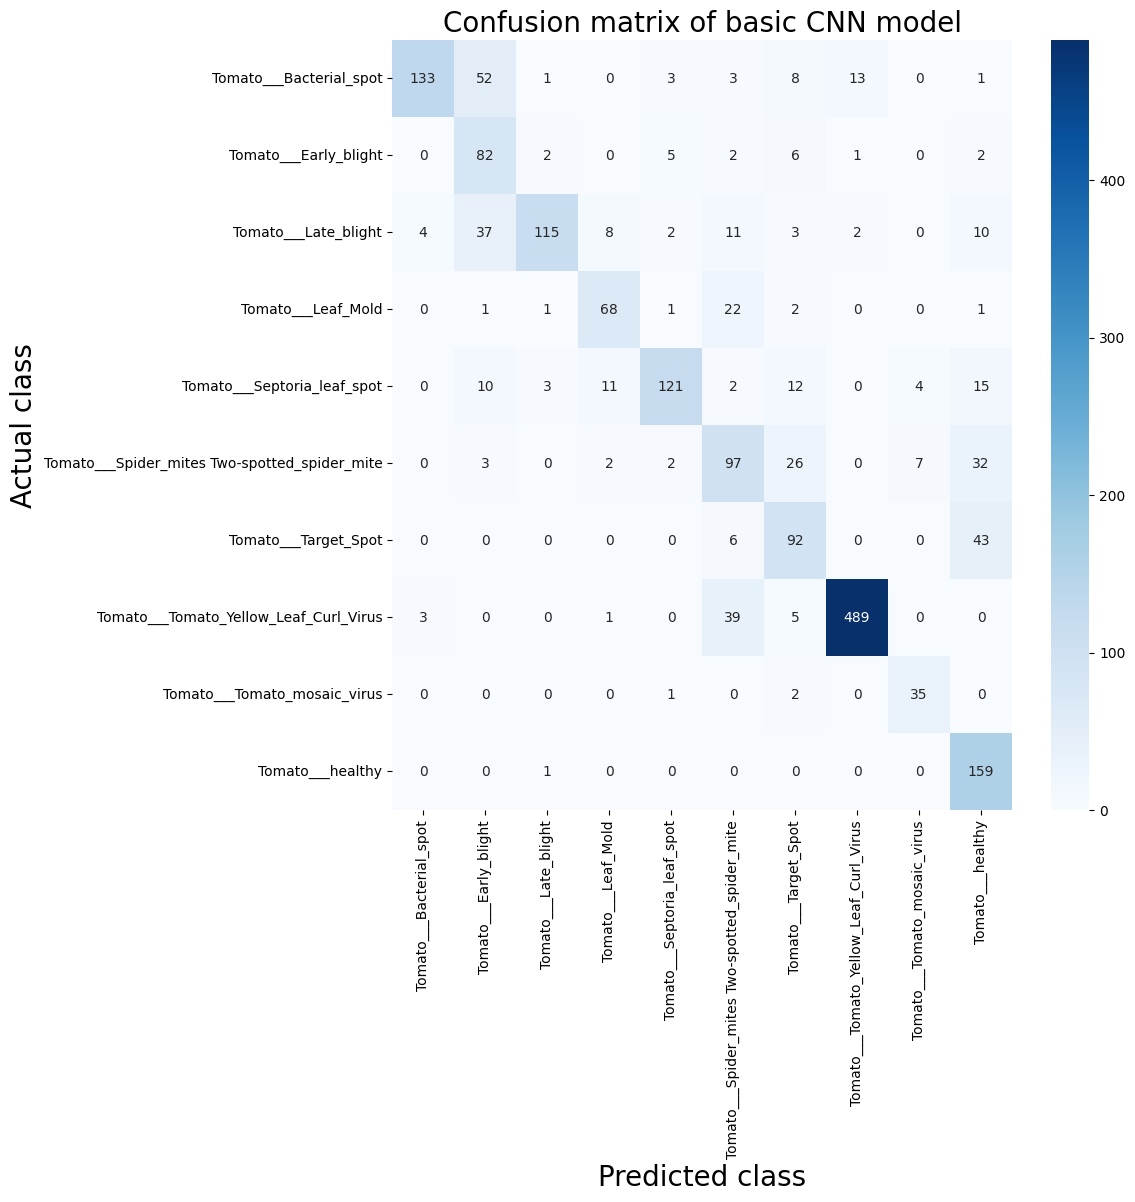

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',xticklabels=class_name,yticklabels=class_name,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of basic CNN model",fontsize=20)
plt.show()

# **MobileNet**

# Importing libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# Preprocessing Datasets

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_data = datasets.ImageFolder("/content/unzipped_plantvillage_data/PlantVillage/train",transform=transform)
val_data = datasets.ImageFolder("/content/unzipped_plantvillage_data/PlantVillage/val",transform=transform)
test_data = datasets.ImageFolder("/content/unzipped_plantvillage_data/PlantVillage/test",transform=transform)

In [ ]:
train_loader = torch.utils.data.DataLoader(train_data,batch_size=16,shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data,batch_size=16,shuffle=False)
test_loader = torch.utils.data.DataLoader(test_data,batch_size=16,shuffle=False)

# loading MobileNet_v2

In [ ]:
model = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]


In [ ]:
for param in model.features.parameters():
  param.requires_grad = False

In [ ]:
num_classes = len(train_data.classes)
num_classes

10

In [ ]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features,num_classes)

# Train model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model= model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
for epoch in range(15):
  model.train()
  running_loss=0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
print("Training complete!")

Epoch 1, Loss: 0.2841553863374894
Epoch 2, Loss: 0.2998681313672107
Epoch 3, Loss: 0.2762710544083776
Epoch 4, Loss: 0.28070453525467526
Epoch 5, Loss: 0.2747114076307823
Epoch 6, Loss: 0.28394044315342953
Epoch 7, Loss: 0.2799940390836977
Epoch 8, Loss: 0.27303873491576064
Epoch 9, Loss: 0.2871291301875285
Epoch 10, Loss: 0.2888889234292009
Epoch 11, Loss: 0.28477261399956405
Epoch 12, Loss: 0.28359164161036315
Epoch 13, Loss: 0.2844243268254172
Epoch 14, Loss: 0.2738504025452162
Epoch 15, Loss: 0.26606443556285125
Training complete!


evaluation of accuracy

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 96.14%


# save model for prediction

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/mobilenet_tomato.pth")

# Evaluation of the model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
model.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs,1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

classification report

In [ ]:
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.99      0.96      0.98       214
                        Tomato___Early_blight       0.94      0.83      0.88       100
                         Tomato___Late_blight       0.94      0.95      0.95       192
                           Tomato___Leaf_Mold       0.96      0.95      0.95        96
                  Tomato___Septoria_leaf_spot       0.95      0.94      0.95       178
Tomato___Spider_mites Two-spotted_spider_mite       0.94      0.96      0.95       169
                         Tomato___Target_Spot       0.89      0.94      0.91       141
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.99      0.99       537
                 Tomato___Tomato_mosaic_virus       0.95      0.97      0.96        38
                             Tomato___healthy       0.97      0.99      0.98       160

                                     accu

confusion matrix

In [ ]:
cm  = confusion_matrix(all_labels,all_preds)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[206   1   1   0   1   0   1   4   0   0]
 [  1  83   7   0   4   1   4   0   0   0]
 [  0   0 183   1   0   1   3   2   0   2]
 [  1   0   0  91   2   0   1   0   1   0]
 [  0   1   3   2 168   1   2   0   1   0]
 [  0   0   0   1   1 162   4   0   0   1]
 [  0   1   0   0   1   5 132   0   0   2]
 [  0   1   0   0   0   2   0 534   0   0]
 [  0   0   0   0   0   0   1   0  37   0]
 [  0   1   0   0   0   0   0   0   0 159]]


matrix visualization

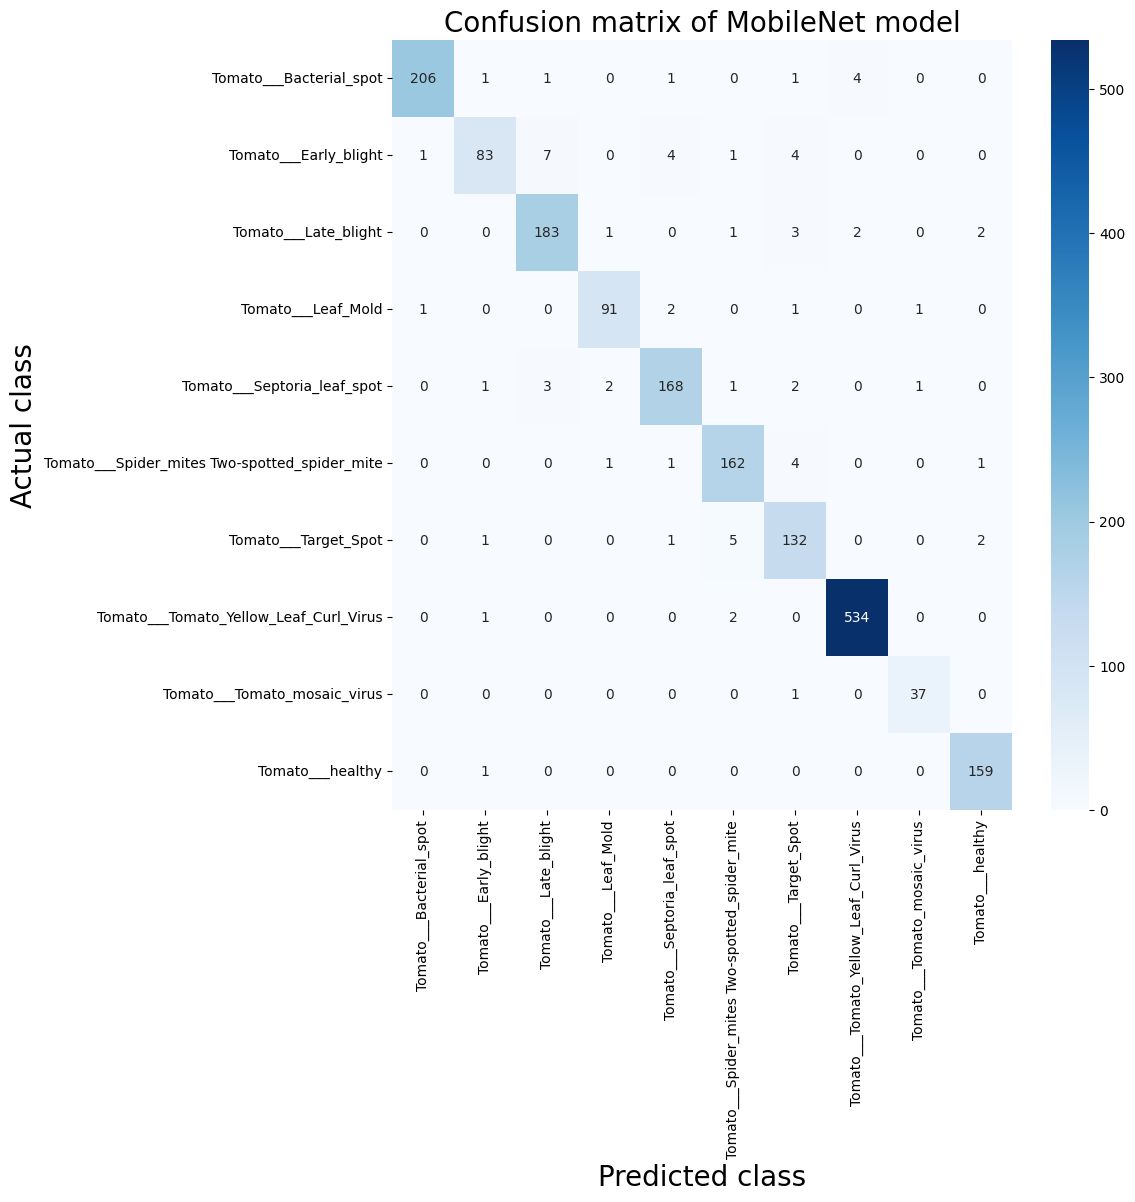

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_data.classes,yticklabels=train_data.classes,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of MobileNet model",fontsize=20)
plt.show()

each row -> Actual class(ground truth)
each column -> predicted class
diagonal values -> correctly classified samples.
off-diagonal values -> misclassification

# **LeNet Model**

## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


## Define lenet Archietecture

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_classes):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)   # 3 channels (RGB leaves)
        self.pool1 = nn.AvgPool2d(2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, stride=2)
        self.fc1 = nn.Linear(16*13*13, 120)  # depends on input size (224x224)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


## Data Preparation

In [ ]:
data_dir = "/content/unzipped_plantvillage_data"  # path to dataset root
transform_train = transforms.Compose([
    transforms.Resize((64,64)),   # resize for consistency
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])
transform_val = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])


train_dataset = datasets.ImageFolder(os.path.join(data_dir, "/content/unzipped_plantvillage_data/PlantVillage/train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "/content/unzipped_plantvillage_data/PlantVillage/val"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

num_classes = len(train_dataset.classes)


## Initialize Model, Loss, Optimizer

In [ ]:
device = torch.device("cpu")
model = LeNet5(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training Loop

In [ ]:

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy :{correct / total:.4f} ")


Epoch 1, Loss: 0.9336, Accuracy :0.6799 
Epoch 2, Loss: 0.6448, Accuracy :0.7821 
Epoch 3, Loss: 0.4976, Accuracy :0.8300 
Epoch 4, Loss: 0.3983, Accuracy :0.8658 
Epoch 5, Loss: 0.3379, Accuracy :0.8820 
Epoch 6, Loss: 0.2863, Accuracy :0.9017 
Epoch 7, Loss: 0.2562, Accuracy :0.9124 
Epoch 8, Loss: 0.2213, Accuracy :0.9225 
Epoch 9, Loss: 0.1939, Accuracy :0.9343 
Epoch 10, Loss: 0.1801, Accuracy :0.9375 


In [ ]:
model.eval()
val_loss, val_correct = 0.0,0
with torch.no_grad():
  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    val_loss += loss.item()
    val_correct += (outputs.argmax(1) == labels).sum().item()
print(f"Validation Loss: {val_loss/len(val_loader):.4f}, "
      f"Accuracy: {val_correct/len(val_dataset):.4f}")

Validation Loss: 0.2972, Accuracy: 0.9023


## save model

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/lenet_tomato.pth")

## Evaluation

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


## Classification Report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print("\n Classification Report : ")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


 Classification Report : 
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.95      0.87      0.91       212
                        Tomato___Early_blight       0.81      0.46      0.59       100
                         Tomato___Late_blight       0.86      0.91      0.88       190
                           Tomato___Leaf_Mold       0.88      0.91      0.89        95
                  Tomato___Septoria_leaf_spot       0.86      0.91      0.88       177
Tomato___Spider_mites Two-spotted_spider_mite       0.93      0.93      0.93       167
                         Tomato___Target_Spot       0.80      0.86      0.83       140
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.94      0.99      0.96       535
                 Tomato___Tomato_mosaic_virus       0.80      1.00      0.89        37
                             Tomato___healthy       0.98      0.91      0.94       159

              

## Confusion Matrix

In [ ]:
cm  = confusion_matrix(all_labels,all_preds)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[184   4   2   0   0   0   0  21   0   1]
 [  6  46  19   3   7   3   8   8   0   0]
 [  1   6 173   2   5   0   1   1   0   1]
 [  0   0   3  86   1   2   1   2   0   0]
 [  0   0   2   2 161   0   3   2   7   0]
 [  1   0   1   2   1 155   7   0   0   0]
 [  0   0   0   0  11   3 121   2   2   1]
 [  2   1   1   0   0   3   0 528   0   0]
 [  0   0   0   0   0   0   0   0  37   0]
 [  0   0   0   3   2   0  10   0   0 144]]


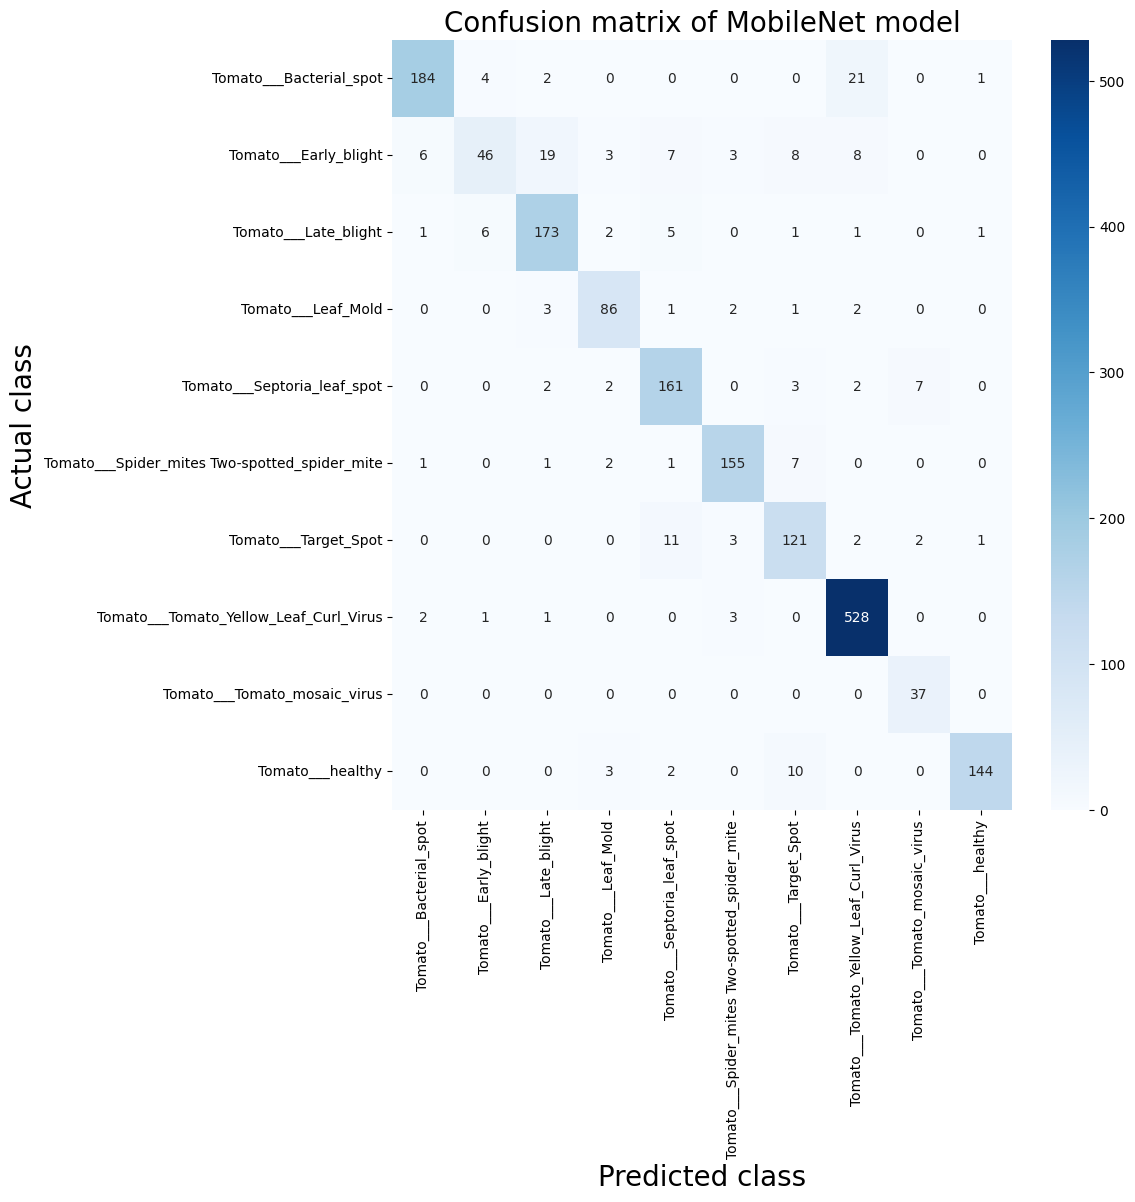

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_dataset.classes,yticklabels=train_dataset.classes,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of MobileNet model",fontsize=20)
plt.show()

# **AlexNet**

## Importing library

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

## Data Transforms

In [ ]:
data_transforms = {
    'train' : transforms.Compose([
        transforms.Resize((227,227)),

        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val' : transforms.Compose([
        transforms.Resize((227,227)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

In [ ]:
data_dir = "/content/unzipped_plantvillage_data"
train_dataset = datasets.ImageFolder(root=data_dir + '/PlantVillage/train', transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(root=data_dir + '/PlantVillage/val', transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)

In [ ]:
model = models.alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model.classifier[6] = nn.Linear(4096,10)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
for epoch in range(10):
  model.train()
  running_loss, correct = 0.0, 0
  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    correct += (outputs.argmax(1) == labels).sum().item()
print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f},Acc: {correct/len(train_dataset):.4f}")

Epoch 10, Loss: 0.0553,Acc: 0.9814


In [ ]:
model.eval()
val_loss, val_correct = 0.0,0
with torch.no_grad():
  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    val_loss += loss.item()
    val_correct += (outputs.argmax(1) == labels).sum().item()
print(f"Validation Loss: {val_loss/len(val_loader):.4f}, "
      f"Accuracy: {val_correct/len(val_dataset):.4f}")

Validation Loss: 0.0426, Accuracy: 0.9845


save model

- Use state_dict if you want flexibility (e.g., retraining, fine‑tuning, deployment).


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/alexnet_tomato.pth")


model = models.alexnet(pretrained=True)
model.classifier[6] = nn.Linear(4096, 10)   # same architecture
model.load_state_dict(torch.load("alexnet_tomato.pth"))
model.eval()

eval model

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print("\n Classification Report : ")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


 Classification Report : 
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.99      1.00      0.99       212
                        Tomato___Early_blight       0.95      0.94      0.94       100
                         Tomato___Late_blight       0.98      0.98      0.98       190
                           Tomato___Leaf_Mold       1.00      0.97      0.98        95
                  Tomato___Septoria_leaf_spot       0.98      0.98      0.98       177
Tomato___Spider_mites Two-spotted_spider_mite       1.00      0.95      0.97       167
                         Tomato___Target_Spot       0.92      1.00      0.96       140
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      1.00      1.00       535
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00        37
                             Tomato___healthy       0.99      1.00      1.00       159

              

In [ ]:
cm  = confusion_matrix(all_labels,all_preds)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[212   0   0   0   0   0   0   0   0   0]
 [  1  94   3   0   0   0   2   0   0   0]
 [  0   2 186   0   1   0   1   0   0   0]
 [  0   1   0  92   2   0   0   0   0   0]
 [  1   2   0   0 173   0   1   0   0   0]
 [  0   0   0   0   0 158   8   0   0   1]
 [  0   0   0   0   0   0 140   0   0   0]
 [  1   0   0   0   0   0   1 533   0   0]
 [  0   0   0   0   0   0   0   0  37   0]
 [  0   0   0   0   0   0   0   0   0 159]]


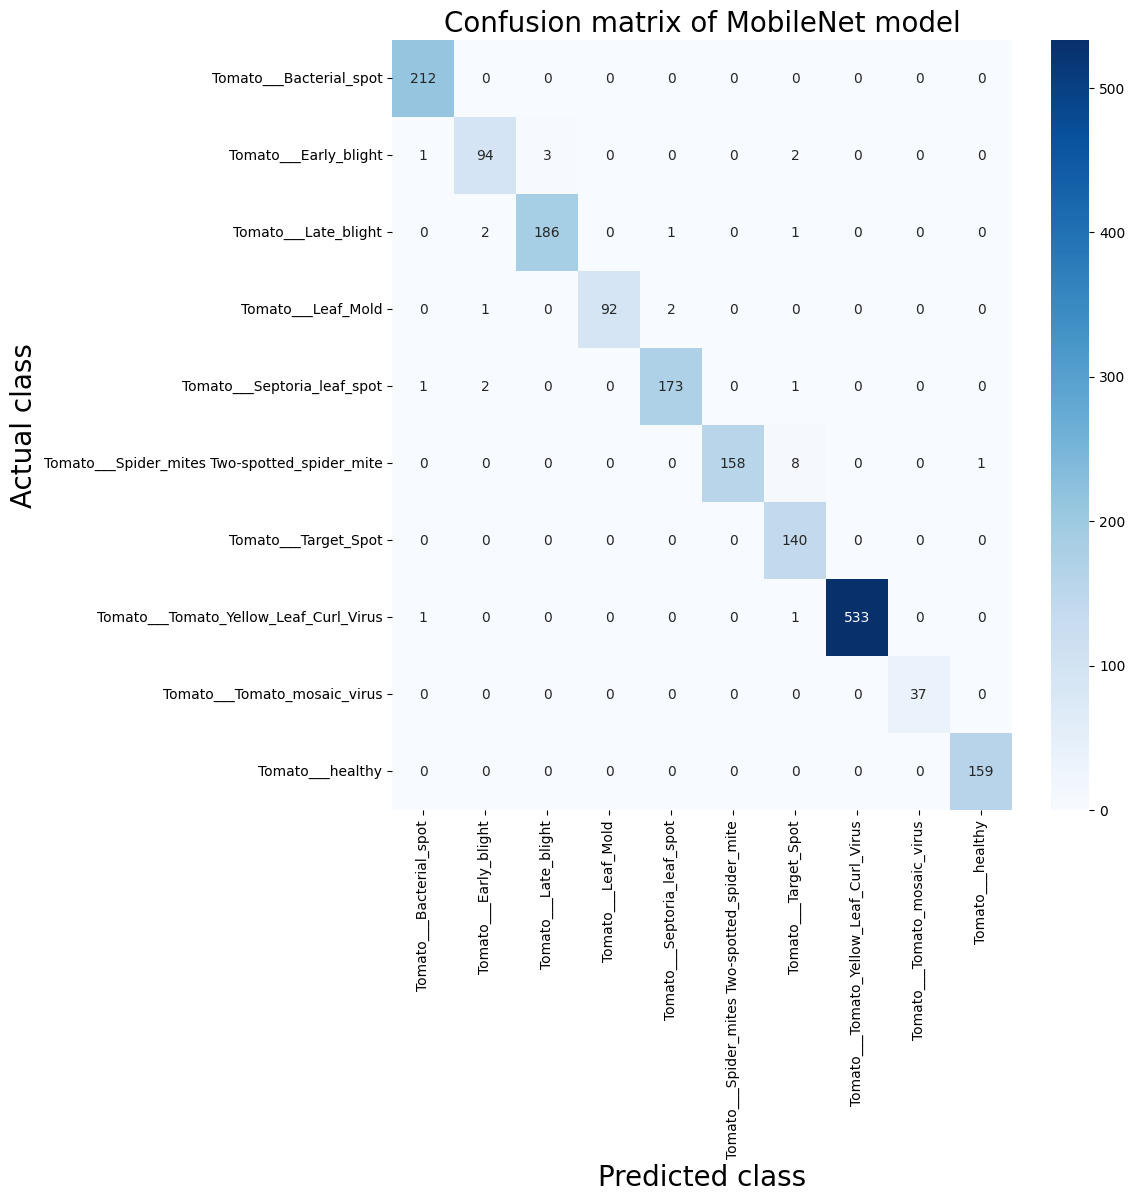

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_dataset.classes,yticklabels=train_dataset.classes,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of MobileNet model",fontsize=20)
plt.show()

# **DenseNet**

import libaries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader



*   Add stronger augmentations to diversify samples, especially for class 1 and class 5
*   This makes the model more robust to variations in leaf orientation, lighting, and size.



In [ ]:
data_transforms = {
    'train' : transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(25),
        transforms.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.3),####
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),###
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val' : transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

In [ ]:
data_dir = "/content/unzipped_plantvillage_data"
train_dataset = datasets.ImageFolder(root=data_dir + '/PlantVillage/train', transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(root=data_dir + '/PlantVillage/val', transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device : ",device)

Using device :  cuda


In [ ]:
model = models.densenet121(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 151MB/s]


In [ ]:
for param in model.features[-3:].parameters():
  param.requires_grad = True

In [ ]:
model.classifier = nn.Linear(model.classifier.in_features,10)
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
for epoch in range(10):
  model.train()
  running_loss, correct = 0.0, 0
  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    correct += (outputs.argmax(1) == labels).sum().item()
  print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f},Acc: {correct/len(train_dataset):.4f}")

Epoch 1, Loss: 0.0059,Acc: 0.9981
Epoch 2, Loss: 0.0099,Acc: 0.9969
Epoch 3, Loss: 0.0059,Acc: 0.9984
Epoch 4, Loss: 0.0060,Acc: 0.9977
Epoch 5, Loss: 0.0058,Acc: 0.9981
Epoch 6, Loss: 0.0043,Acc: 0.9984
Epoch 7, Loss: 0.0042,Acc: 0.9986
Epoch 8, Loss: 0.0028,Acc: 0.9990
Epoch 9, Loss: 0.0017,Acc: 0.9995
Epoch 10, Loss: 0.0027,Acc: 0.9992


In [ ]:
model.eval()
val_loss, val_correct = 0.0,0
with torch.no_grad():
  for inputs, labels in val_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    val_loss += loss.item()
    val_correct += (outputs.argmax(1) == labels).sum().item()
print(f"Validation Loss: {val_loss/len(val_loader):.4f}, "
      f"Accuracy: {val_correct/len(val_dataset):.4f}")

Validation Loss: 0.0095, Accuracy: 0.9967


In [ ]:
torch.save(model.state_dict(),"/content/drive/MyDrive/densenet_tomato.pth")
print("Model saved as densenet_tomato.pth")

Model saved as densenet_tomato.pth


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print("\n Classification Report : ")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


 Classification Report : 
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      1.00      1.00       212
                        Tomato___Early_blight       0.99      0.99      0.99       100
                         Tomato___Late_blight       0.99      0.99      0.99       190
                           Tomato___Leaf_Mold       1.00      0.99      0.99        95
                  Tomato___Septoria_leaf_spot       0.99      1.00      1.00       177
Tomato___Spider_mites Two-spotted_spider_mite       0.99      1.00      1.00       167
                         Tomato___Target_Spot       1.00      0.99      1.00       140
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      1.00      1.00       535
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00        37
                             Tomato___healthy       0.99      1.00      1.00       159

              

In [ ]:
cm  = confusion_matrix(all_labels,all_preds)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[211   1   0   0   0   0   0   0   0   0]
 [  0  99   0   0   1   0   0   0   0   0]
 [  0   0 189   0   0   0   0   0   0   1]
 [  0   0   0  94   0   1   0   0   0   0]
 [  0   0   0   0 177   0   0   0   0   0]
 [  0   0   0   0   0 167   0   0   0   0]
 [  1   0   0   0   0   0 139   0   0   0]
 [  0   0   1   0   0   0   0 534   0   0]
 [  0   0   0   0   0   0   0   0  37   0]
 [  0   0   0   0   0   0   0   0   0 159]]


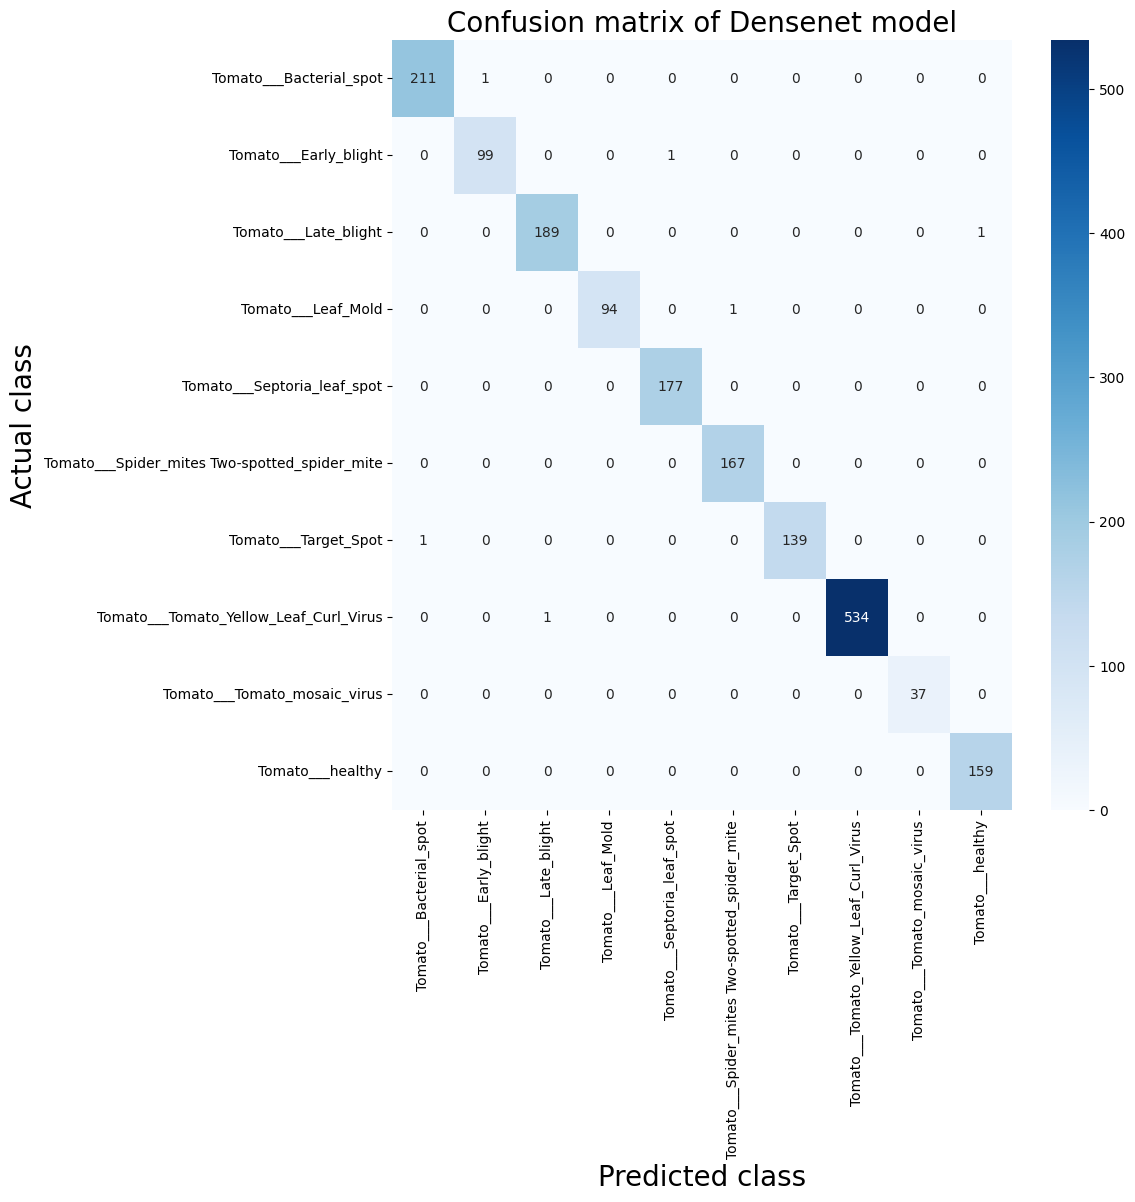

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_dataset.classes,yticklabels=train_dataset.classes,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of Densenet model",fontsize=20)
plt.show()

# **ResNet50**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
data_dir = "/content/unzipped_plantvillage_data"
train_dataset = datasets.ImageFolder(root=data_dir + '/PlantVillage/train', transform=transform_train)
val_dataset = datasets.ImageFolder(root=data_dir + '/PlantVillage/val', transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [7]:
model = models.resnet50(pretrained=True)
for param in model.parameters():
  param.requires_grad = False

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
num_epochs = 10
train_acc, val_acc = [],[]
train_loss, val_loss = [], []

for epoch in range(num_epochs):
  model.train()
  correct, total, running_loss = 0, 0 ,0
  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

  train_acc.append(correct/total)
  train_loss.append(running_loss/len(train_loader))

  model.eval()
  correct, total, running_loss = 0, 0 ,0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      running_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

  val_acc.append(correct/total)
  val_loss.append(running_loss/len(val_loader))

  print(f"Epoch {epoch+1}/{num_epochs}, "
        f"Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

Epoch 1/10, Train Acc: 0.9037, Val Acc: 0.8996
Epoch 2/10, Train Acc: 0.9023, Val Acc: 0.9045
Epoch 3/10, Train Acc: 0.9068, Val Acc: 0.9178
Epoch 4/10, Train Acc: 0.9107, Val Acc: 0.8996
Epoch 5/10, Train Acc: 0.9111, Val Acc: 0.9117
Epoch 6/10, Train Acc: 0.9127, Val Acc: 0.9299
Epoch 7/10, Train Acc: 0.9152, Val Acc: 0.9134
Epoch 8/10, Train Acc: 0.9200, Val Acc: 0.9249
Epoch 9/10, Train Acc: 0.9176, Val Acc: 0.9123
Epoch 10/10, Train Acc: 0.9212, Val Acc: 0.9216


In [18]:
torch.save(model.state_dict(),"/content/drive/MyDrive/resnet_tomato.pth")
print("Model saved as resnet_tomato.pth")

Model saved as resnet_tomato.pth


In [11]:
from sklearn.metrics import classification_report

In [13]:
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [15]:
print("\n Classification Report : ")
print(classification_report(y_true, y_pred, target_names=train_dataset.classes))


 Classification Report : 
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.91      0.98      0.94       212
                        Tomato___Early_blight       0.64      0.87      0.74       100
                         Tomato___Late_blight       0.97      0.89      0.93       190
                           Tomato___Leaf_Mold       0.89      0.88      0.89        95
                  Tomato___Septoria_leaf_spot       0.99      0.85      0.92       177
Tomato___Spider_mites Two-spotted_spider_mite       0.81      0.99      0.89       167
                         Tomato___Target_Spot       0.89      0.84      0.86       140
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.96      0.98       535
                 Tomato___Tomato_mosaic_virus       0.97      0.84      0.90        37
                             Tomato___healthy       1.00      0.91      0.95       159

              

In [16]:
cm  = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[207   4   0   0   0   0   0   1   0   0]
 [  3  87   1   1   0   5   3   0   0   0]
 [  1  14 169   2   0   1   3   0   0   0]
 [  0   6   1  84   0   3   1   0   0   0]
 [  2  17   1   2 151   2   1   0   1   0]
 [  0   0   0   0   0 166   1   0   0   0]
 [  4   3   1   1   0  13 118   0   0   0]
 [ 11   1   2   4   0   4   1 512   0   0]
 [  0   2   0   0   1   3   0   0  31   0]
 [  0   1   0   0   0   8   5   0   0 145]]


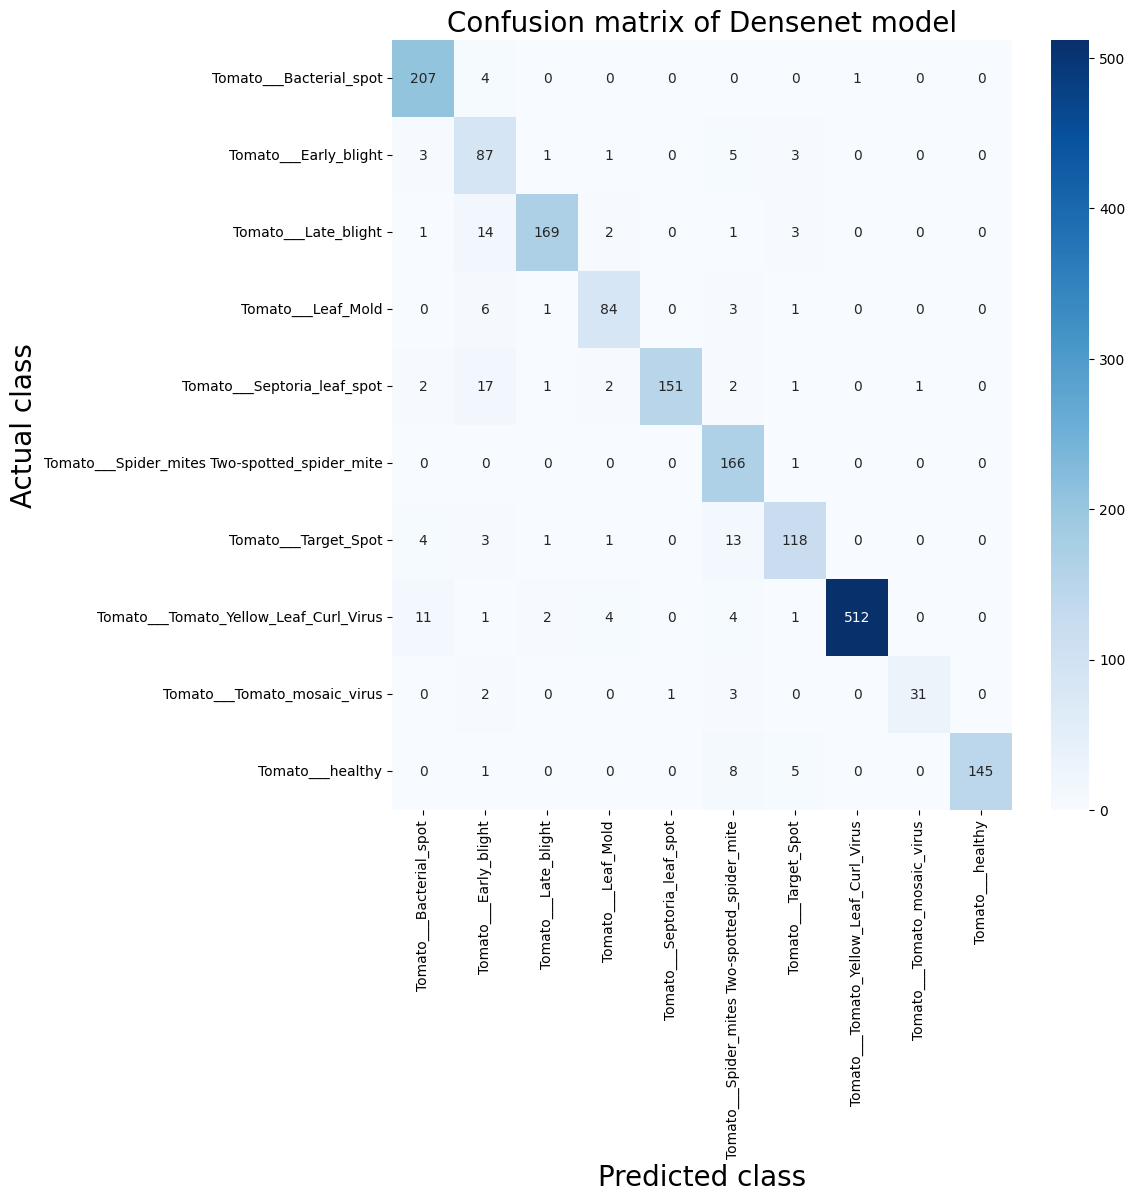

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_dataset.classes,yticklabels=train_dataset.classes,annot_kws={'size':10})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of Densenet model",fontsize=20)
plt.show()